# PLot QC improvement with added FC

In [2]:
library(tidyverse)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [40]:
qc_asm <- read_tsv("../../assembly/qc/qc_flowcells.tsv", col_type = 'cdccc')
head(qc_asm)



Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


metric,value,haplotype,asm_method,asm_name,source
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,19122,NA,unphased_verkko,TUE_02_01UL,stat
Number of primary alignments,45269,NA,unphased_verkko,TUE_02_01UL,stat
Number of secondary alignments,34659,NA,unphased_verkko,TUE_02_01UL,stat
Number of primary alignments with >65535 CIGAR operations,0,NA,unphased_verkko,TUE_02_01UL,stat
Number of bases in mapped sequences,6685275250,NA,unphased_verkko,TUE_02_01UL,stat
Number of mapped bases,6642871159,NA,unphased_verkko,TUE_02_01UL,stat


In [41]:
n_UL = c(1,2,3,4,5,6)
n_DX = c(0,1,2)
samples = c("TUE_02")

In [61]:
combinations <- as_tibble(expand.grid("n_UL" = as.factor(n_UL), "n_DX" = as.factor(n_DX), "sample" = samples)) %>%
    mutate(asm_name = ifelse(n_DX == 0,
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL"),
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL", "_", str_pad(n_DX, 2, pad = "0"), "DX")))

In [62]:
dt <- inner_join(
  combinations,
  qc_asm,
  by = join_by("asm_name"),
)

head(dt)

n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source
<fct>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Number of mapped sequences,19122,NA,unphased_verkko,stat
1,0,TUE_02,TUE_02_01UL,Number of primary alignments,45269,NA,unphased_verkko,stat
1,0,TUE_02,TUE_02_01UL,Number of secondary alignments,34659,NA,unphased_verkko,stat
1,0,TUE_02,TUE_02_01UL,Number of primary alignments with >65535 CIGAR operations,0,NA,unphased_verkko,stat
1,0,TUE_02,TUE_02_01UL,Number of bases in mapped sequences,6685275250,NA,unphased_verkko,stat
1,0,TUE_02,TUE_02_01UL,Number of mapped bases,6642871159,NA,unphased_verkko,stat


In [64]:
source("../scripts/13_process_assembly_qc.R")

dt_processed <- process_qc_table(dt)

In [77]:
metrics <- dt_processed %>% select('metric') %>% unique() %>% pull()
for (i in 1:length(metrics))
{
    print(paste("Plotting", metrics[i]))
    p <- ggplot(dt_processed %>% filter(metric == metrics[i]), aes(x = n_UL, y = value, fill = n_DX)) +
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c( "#E69F00", "#56B4E9", "#009E73","#999999", "#F0E442")) +
        theme_classic() +
        labs(
            x = "n UL Flowcells",
            y = metrics[i],
            fill = "n DX Flowcells"
         )
    ggsave(paste0("../../doc/img/flowcells/", metrics[i], ".png"), p)
}

 [1] "Assembly Length"                   "% of Ref covered by Assembly"     
 [3] "% of Ref duplicated in Assembly"   "% of Assembly covered by Ref"     
 [5] "NG75"                              "NG50"                             
 [7] "NGA50"                             "Average Ungapped Alignment length"
 [9] "Number of Breaks in Assembly"      "Quality Value"                    
[11] "Error Rate"                        "Number of T2T chromosomes"        
[13] "Genome Completeness"               "Missing Multi-Copy Genes (%)"     
[1] "Plotting Assembly Length"


Saving 7 x 7 in image


[1] "Plotting % of Ref covered by Assembly"


Saving 7 x 7 in image


[1] "Plotting % of Ref duplicated in Assembly"


...

Saving 7 x 7 in image


[1] "Plotting Genome Completeness"


Saving 7 x 7 in image


[1] "Plotting Missing Multi-Copy Genes (%)"


Saving 7 x 7 in image


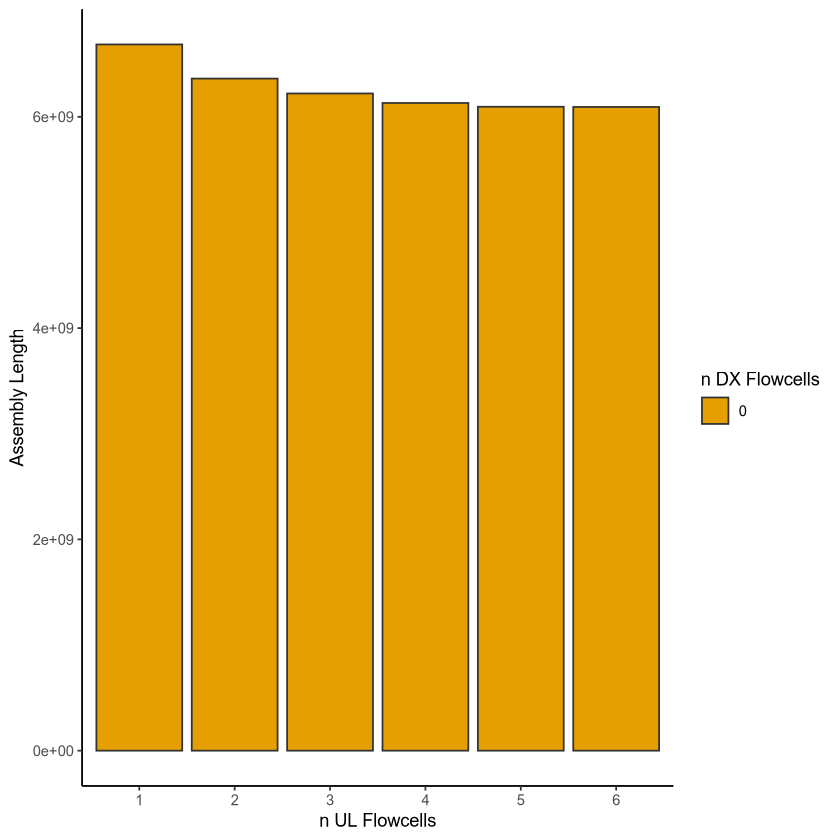

In [68]:
m <- "Assembly Length"

